# Fit statistical models to N<sub>2</sub>O and CH<sub>4</sub> data

Model is 

**Full model**
$$
\ln{F_{i,k}} = \alpha_k + \beta_k f(T_{i}) + \sum_{j=1}^{N} \gamma_{j,k}x_{i,j} \\

f(T_{i}) = \frac{T_{i,j} - 10^{\circ} \text{C}}{10^{\circ} \text{C}}
$$

The model is run with 9, 6, 5, 4 and 3 surface types

In [6]:
import pandas as pd
from dotenv import load_dotenv; load_dotenv()

import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.metrics import r2_score, mean_squared_error

import pymc as pm
import arviz as az

import cloudpickle

%matplotlib widget
%load_ext autoreload
%autoreload 2

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


# Define model functions

In [1]:
def full_model(T,X,y, alpha_mu_mean=0.0, alpha_mu_std=2.0, gamma_std=2.0, lambda_beta=1.0, lambda_epsilon=1.0):
    coords = {'st': X.columns.to_list(), 'obs_id': np.arange(y.shape[0])}
    with pm.Model(coords_mutable=coords) as model:
        alpha = pm.Normal("alpha", mu=alpha_mu_mean, sigma=alpha_mu_std)
        beta = pm.Exponential('beta', lambda_beta)

        gamma_mu = pm.Normal("gamma_mu", mu=0, sigma=1)
        gamma = pm.Normal("gamma", mu=gamma_mu, sigma=gamma_std, dims='st')

        epsilon = pm.Exponential("sigma", lambda_epsilon)

        T = pm.MutableData("T_air", np.repeat(T.reshape(T.shape[0],1), repeats=len(coords['st']), axis=1), dims=("obs_id","st"))
        ST = pm.MutableData("ST", X.values, dims=("obs_id", "st"))

        mu = alpha + beta*(T[:,0]-10)/10  + pm.math.sum(gamma*ST, axis=1)

        y = pm.Normal("obs", mu=mu, sigma=epsilon, observed=y)

        idata = pm.sample_prior_predictive(samples=2000)

    return model, idata

In [2]:
full_model_eq = lambda T,X,params,inds: params['alpha'] + params['beta']*((T[inds, 0]-10)/10) + np.sum(params['gamma']*X[inds, :],axis=1)

In [3]:
def fit_model(model, draws=2000, tune=2000, chains=4):
    with model:
        model_res = pm.sample(draws, tune=tune, chains=chains)
    return model_res

# Define visualization functions

In [4]:
def visualize_fit(model, obs, prior_values, posterior, xlabel, ylabel, color_var=None, cb_label='', axs=None):
    # NB! These works only for negative values of model and obs
    # Figure definitions
    if axs is None:
        fig, axs = plt.subplots(figsize=(10,10), nrows=2, ncols=2)
        axs = axs.flatten()
        fig.subplots_adjust(bottom=0.2, hspace=0.3, wspace=0.3)
    fs=14
    ls=10


    # Find min and max value between model and measurements

    if np.min(model) < model.min():
        min_all = np.min(model)
    else:
        min_all = obs.min()
    min_all = min_all*1.15

    if np.max(model) > model.max():
        max_all = np.max(model)
    else:
        max_all = obs.max()
    max_all = max_all*1.15

    # Fig. 1
    bins, counts, _ = axs[0].hist(obs, bins=100, color='goldenrod', density=True, label=f'Measured {xlabel}')
    bins, counts, _ = axs[0].hist(prior_values, bins = np.linspace(-10,10,201), alpha=0.75, density=True, label='Prior')

    axs[0].legend(loc='best')
    axs[0].set_xlabel(xlabel, fontsize=fs)
    axs[0].tick_params(axis='both', labelsize=ls)

    # Fig. 2
    az.plot_ppc(posterior, num_pp_samples=300, ax=axs[1])
    axs[1].set_xlabel(xlabel, fontsize=fs)
    axs[1].tick_params(axis='both', labelsize=ls)

    # Fig. 3
    axs[2].plot(obs.index, obs, 'o', markersize=4, markeredgecolor='k', markeredgewidth=0.5, color='w', label='Measured')
    axs[2].plot(obs.index, model, 'o', color='b', markeredgecolor='k', markeredgewidth=0.5, markersize=4, label='MAP estimate', alpha=.50)

    axs[2].set_ylabel(ylabel, fontsize=fs)

    axs[2].tick_params(axis='both', labelsize=ls)
    axs[2].xaxis.set_major_formatter(mdates.DateFormatter('%y-%m'))
    axs[2].legend(loc='best', prop={'size': ls})

    # Fig. 4
    r2 = r2_score(obs.values, model)
    rmse = mean_squared_error(obs.values, model)
    if color_var is not None:
        im = axs[3].scatter(model, obs, c=color_var, s=3)
        cb = fig.colorbar(im)
        cb.set_label('T$_{\mathrm{air}}$ ($^{\circ}$C)', fontsize=fs)
        cb.ax.tick_params(labelsize=fs-1)
    else:
        im = axs[3].scatter(model, obs, c='gray', s=3)

    axs[3].set_xlabel(f'Modelled {ylabel}', fontsize=fs)
    axs[3].set_ylabel(f'Measured {xlabel}', fontsize=fs)
    axs[3].tick_params(axis='both', labelsize=ls)
    axs[3].text(0.05, 0.95, f'R$^2$ = {np.round(r2, 2)}', fontsize=ls, transform=axs[3].transAxes)

    axs[3].text(0.05, 0.9, f'RMSE = {np.round(rmse, 5)}', fontsize=ls, transform=axs[3].transAxes)
    axs[3].set_xlim(min_all, max_all)
    axs[3].set_ylim(min_all, max_all)
    axs[3].plot((-15,15), (-15,15), 'k--', linewidth=2)

# Load data

In [7]:
data_n2o = pd.read_csv('data/inference_data_n2o.csv', index_col='time')
data_n2o.index = pd.to_datetime(data_n2o.index)

data_ch4 = pd.read_csv('data/inference_data_ch4.csv', index_col='time')
data_ch4.index = pd.to_datetime(data_ch4.index)

# Define surface type dataframes

In [8]:
st_3_n2o = data_n2o.loc[:, ['Exposed peat','All ditches','Residue, ground and vegetation']]
st_4_n2o = data_n2o.loc[:, ['Exposed peat','Ditch','Plant covered ditch','Residue, ground and vegetation']]
st_5_n2o = data_n2o.loc[:, ['Exposed peat','All ditches','Dead wood and residue','Litter','Green vegetation and trees']]
st_6_n2o = data_n2o.loc[:, ['Exposed peat','Ditch','Plant covered ditch','Dead wood and residue','Litter','Green vegetation and trees']]
st_9_n2o = data_n2o.loc[:, ['Dead wood', 'Harvest residue', 'Exposed peat', 'Litter', 'Bottom layer', 'Field layer', 'Ditch', 'Living tree', 'Plant covered ditch',]]

In [9]:
st_3_ch4 = data_ch4.loc[:, ['Exposed peat','All ditches','Residue, ground and vegetation']]
st_4_ch4 = data_ch4.loc[:, ['Exposed peat','Ditch','Plant covered ditch','Residue, ground and vegetation']]
st_5_ch4 = data_ch4.loc[:, ['Exposed peat','All ditches','Dead wood and residue','Litter','Green vegetation and trees']]
st_6_ch4 = data_ch4.loc[:, ['Exposed peat','Ditch','Plant covered ditch','Dead wood and residue','Litter','Green vegetation and trees']]
st_9_ch4 = data_ch4.loc[:, ['Dead wood', 'Harvest residue', 'Exposed peat', 'Litter', 'Bottom layer', 'Field layer', 'Ditch', 'Living tree', 'Plant covered ditch',]]

# N<sub>2</sub>O models

## N<sub>2</sub>O full model

### 3 surface types

In [10]:
full_n2o_st3, idata_full_n2o_st3 = full_model(T=data_n2o.T_air.values, X=st_3_n2o, y = data_n2o.F_N2O_ln.values)

Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma]


In [11]:
full_n2o_st3_res = fit_model(full_n2o_st3)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, gamma_mu, gamma, sigma]
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 959 seconds.


In [12]:
with full_n2o_st3:
        map_estimate_st3, optresult = pm.find_MAP(method="L-BFGS-B", return_raw=True
    )

In [13]:
with full_n2o_st3:
    pm.sample_posterior_predictive(full_n2o_st3_res, extend_inferencedata=True)

Sampling: [obs]


/Users/opa/Ranskalankorpi_CC_EC/.venv/lib/python3.11/site-packages/xarray/core/utils.py:494: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  warnings.warn(


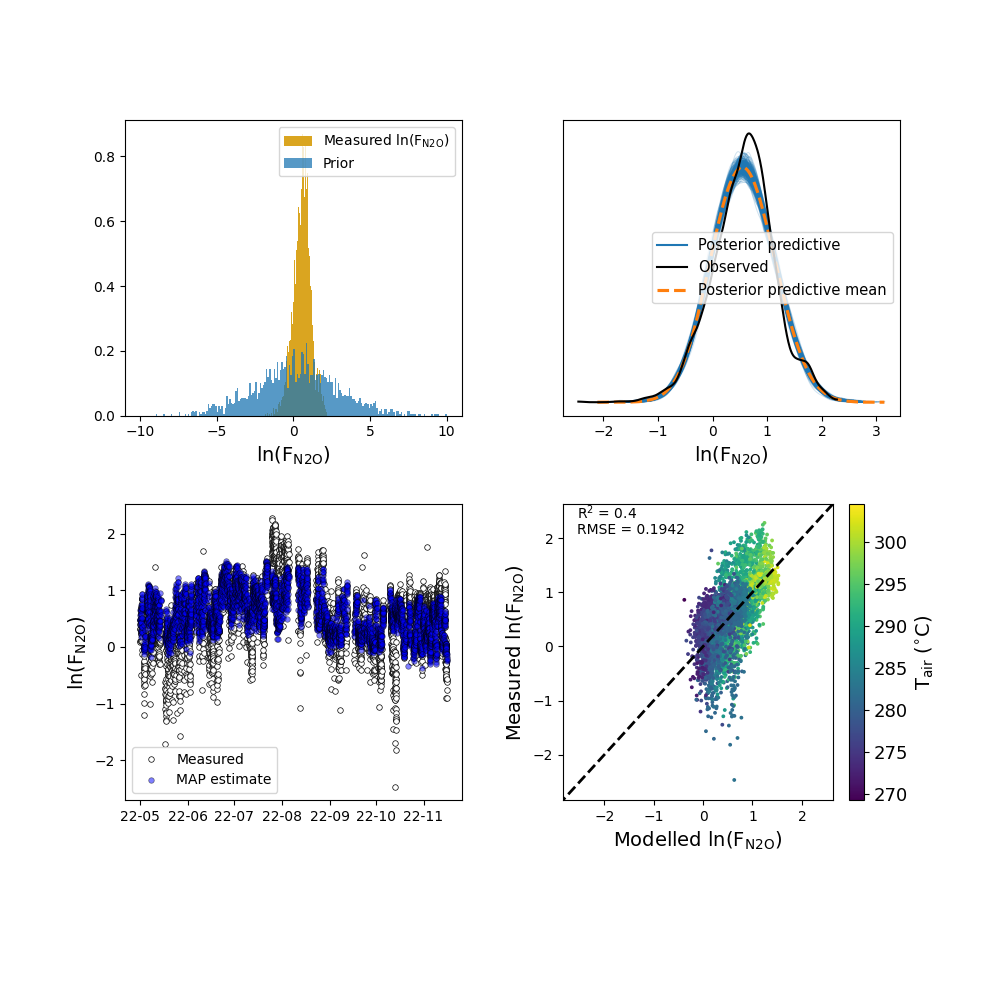

In [14]:
model = full_model_eq(full_n2o_st3['T_air'].eval(), st_3_n2o.values, map_estimate_st3, np.arange(data_n2o.shape[0]))
obs = data_n2o.loc[:, 'F_N2O_ln']

prior = idata_full_n2o_st3['prior']
data_inds = np.random.choice(st_3_n2o.shape[0], size=2000)
pp = {k:np.squeeze(v.to_numpy()) for k,v in prior.items()}
prior_values = full_model_eq(full_n2o_st3['T_air'].eval(), st_3_n2o.values, pp, data_inds)

posterior = full_n2o_st3_res

xlabel = 'ln(F$_{\mathrm{N2O}}$)'
ylabel = 'ln(F$_{\mathrm{N2O}}$)'

color_var = data_n2o.T_air_K.values
cb_label = 'T$_{\mathrm{air}}$ (K)'

visualize_fit(model, obs, prior_values, posterior, xlabel, ylabel, color_var=color_var, cb_label=cb_label, axs=None)

In [15]:
fname = 'models/full_model_n2o_st3_no_ST_T_mutable.pkl'
dict_to_save = {'model': full_n2o_st3,
                'idata': idata_full_n2o_st3,
                'model_res': full_n2o_st3_res,
                'map': map_estimate_st3,
                'data': data_n2o
                }

with open(fname, 'wb') as buff:
    cloudpickle.dump(dict_to_save, buff)

### 4 surface types

In [16]:
full_n2o_st4, idata_full_n2o_st4 = full_model(T=data_n2o.T_air.values, X=st_4_n2o, y = data_n2o.F_N2O_ln.values)

Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma]


In [17]:
full_n2o_st4_res = fit_model(full_n2o_st4)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, gamma_mu, gamma, sigma]
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 626 seconds.


In [18]:
with full_n2o_st4:
        map_estimate_st4, optresult = pm.find_MAP(method="L-BFGS-B", return_raw=True
    )

In [19]:
with full_n2o_st4:
    pm.sample_posterior_predictive(full_n2o_st4_res, extend_inferencedata=True)

Sampling: [obs]


/Users/opa/Ranskalankorpi_CC_EC/.venv/lib/python3.11/site-packages/xarray/core/utils.py:494: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  warnings.warn(


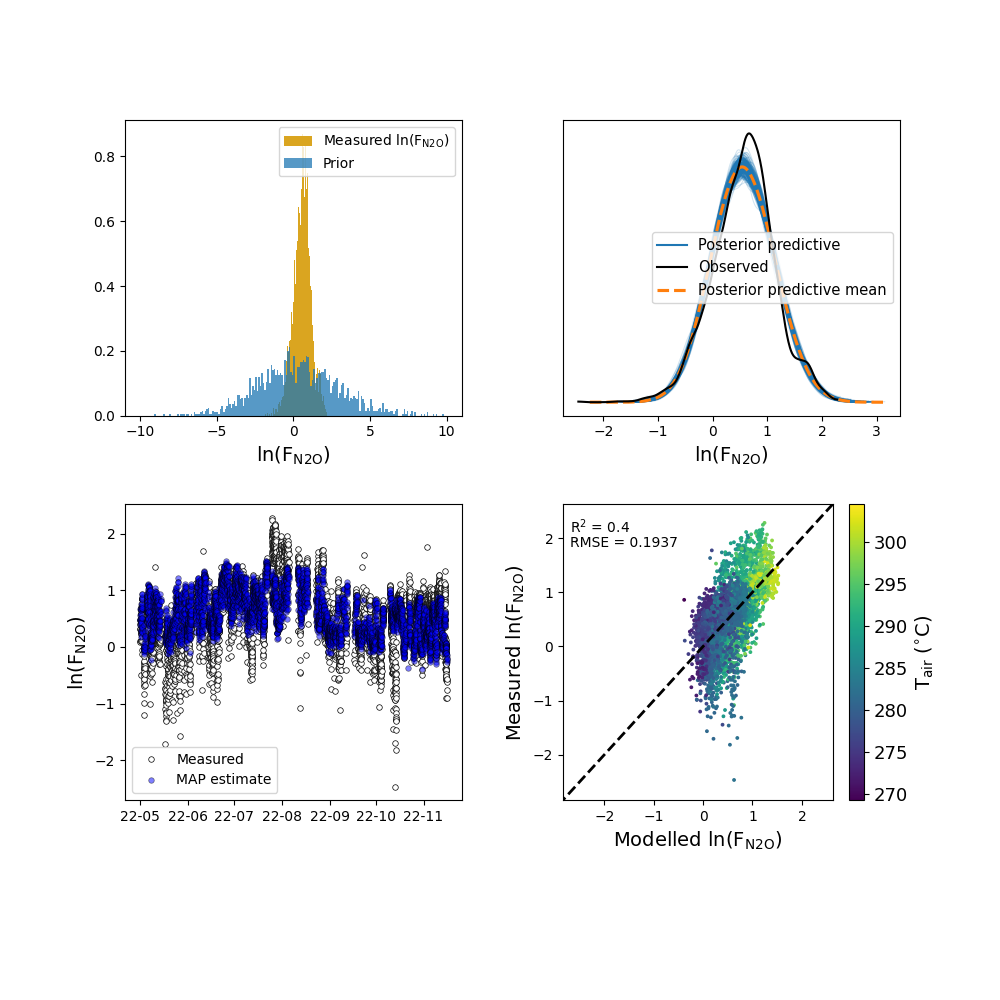

In [20]:
model = full_model_eq(full_n2o_st4['T_air'].eval(), st_4_n2o.values, map_estimate_st4, np.arange(data_n2o.shape[0]))
obs = data_n2o.loc[:, 'F_N2O_ln']

prior = idata_full_n2o_st4['prior']
data_inds = np.random.choice(st_5_n2o.shape[0], size=2000)
pp = {k:np.squeeze(v.to_numpy()) for k,v in prior.items()}
prior_values = full_model_eq(full_n2o_st4['T_air'].eval(), st_4_n2o.values, pp, data_inds)

posterior = full_n2o_st4_res

xlabel = 'ln(F$_{\mathrm{N2O}}$)'
ylabel = 'ln(F$_{\mathrm{N2O}}$)'

color_var = data_n2o.T_air_K.values
cb_label = 'T$_{\mathrm{air}}$ (K)'

visualize_fit(model, obs, prior_values, posterior, xlabel, ylabel, color_var=color_var, cb_label=cb_label, axs=None)

In [21]:
fname = 'models/full_model_n2o_st4_no_ST_T_mutable.pkl'
dict_to_save = {'model': full_n2o_st4,
                'idata': idata_full_n2o_st4,
                'model_res': full_n2o_st4_res,
                'map': map_estimate_st4,
                'data': data_n2o
                }

with open(fname, 'wb') as buff:
    cloudpickle.dump(dict_to_save, buff)

### 5 surface types

In [22]:
full_n2o_st5, idata_full_n2o_st5 = full_model(T=data_n2o.T_air.values, X=st_5_n2o, y = data_n2o.F_N2O_ln.values)

Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma]


In [23]:
full_n2o_st5_res = fit_model(full_n2o_st5)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, gamma_mu, gamma, sigma]
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 672 seconds.


In [24]:
with full_n2o_st5:
        map_estimate_st5, optresult = pm.find_MAP(method="L-BFGS-B", return_raw=True
    )

In [25]:
with full_n2o_st5:
    pm.sample_posterior_predictive(full_n2o_st5_res, extend_inferencedata=True)

Sampling: [obs]


/Users/opa/Ranskalankorpi_CC_EC/.venv/lib/python3.11/site-packages/xarray/core/utils.py:494: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  warnings.warn(


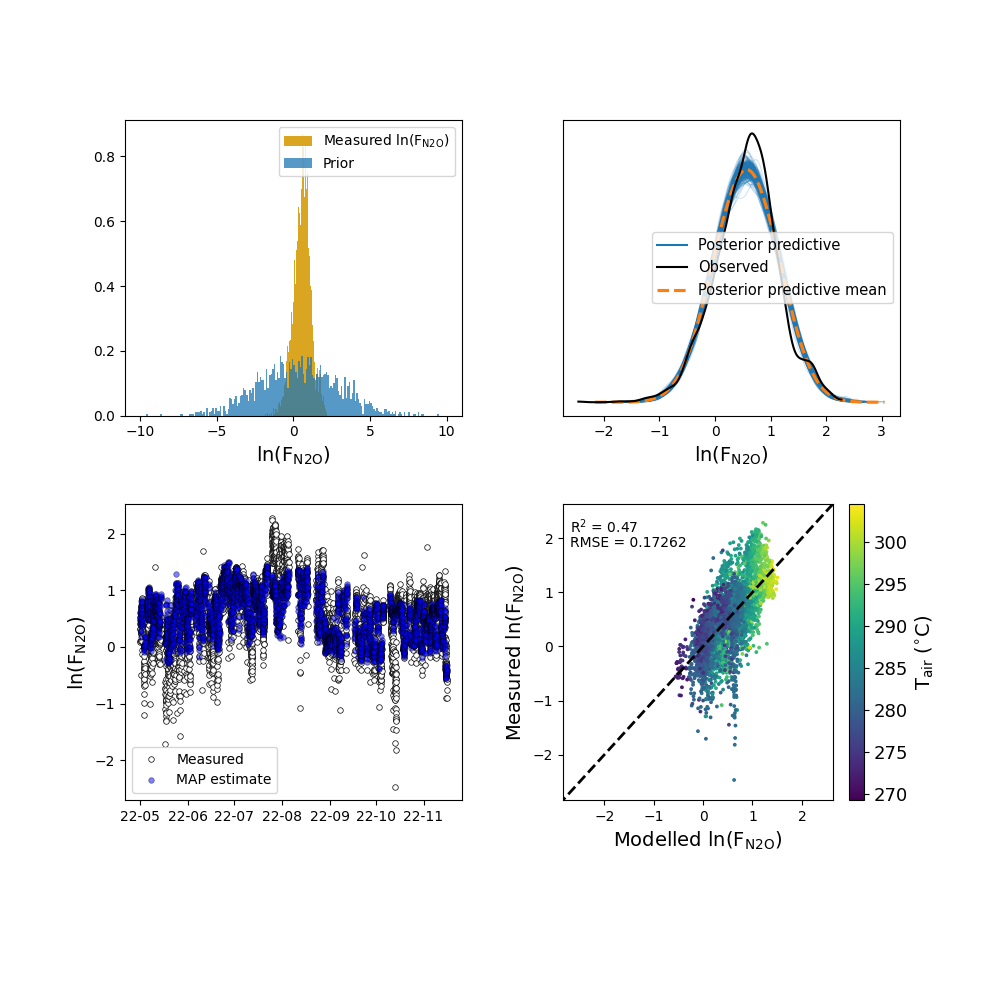

In [26]:
model = full_model_eq(full_n2o_st5['T_air'].eval(), st_5_n2o.values, map_estimate_st5, np.arange(data_n2o.shape[0]))
obs = data_n2o.loc[:, 'F_N2O_ln']

prior = idata_full_n2o_st5['prior']
data_inds = np.random.choice(st_5_n2o.shape[0], size=2000)
pp = {k:np.squeeze(v.to_numpy()) for k,v in prior.items()}
prior_values = full_model_eq(full_n2o_st5['T_air'].eval(), st_5_n2o.values, pp, data_inds)

posterior = full_n2o_st5_res

xlabel = 'ln(F$_{\mathrm{N2O}}$)'
ylabel = 'ln(F$_{\mathrm{N2O}}$)'

color_var = data_n2o.T_air_K.values
cb_label = 'T$_{\mathrm{air}}$ (K)'

visualize_fit(model, obs, prior_values, posterior, xlabel, ylabel, color_var=color_var, cb_label=cb_label, axs=None)

In [27]:
fname = 'models/full_model_n2o_st5_no_ST_T_mutable.pkl'
dict_to_save = {'model': full_n2o_st5,
                'idata': idata_full_n2o_st5,
                'model_res': full_n2o_st5_res,
                'map': map_estimate_st5,
                'data': data_n2o
                }

with open(fname, 'wb') as buff:
    cloudpickle.dump(dict_to_save, buff)

### 6 surface types

In [28]:
full_n2o_st6, idata_full_n2o_st6 = full_model(T=data_n2o.T_air.values, X=st_6_n2o, y = data_n2o.F_N2O_ln.values)

Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma]


In [29]:
full_n2o_st6_res = fit_model(full_n2o_st6)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, gamma_mu, gamma, sigma]
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 874 seconds.


In [30]:
with full_n2o_st6:
        map_estimate_st6, optresult = pm.find_MAP(method="L-BFGS-B", return_raw=True
    )

In [31]:
with full_n2o_st6:
    pm.sample_posterior_predictive(full_n2o_st6_res, extend_inferencedata=True)

Sampling: [obs]


/Users/opa/Ranskalankorpi_CC_EC/.venv/lib/python3.11/site-packages/xarray/core/utils.py:494: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  warnings.warn(


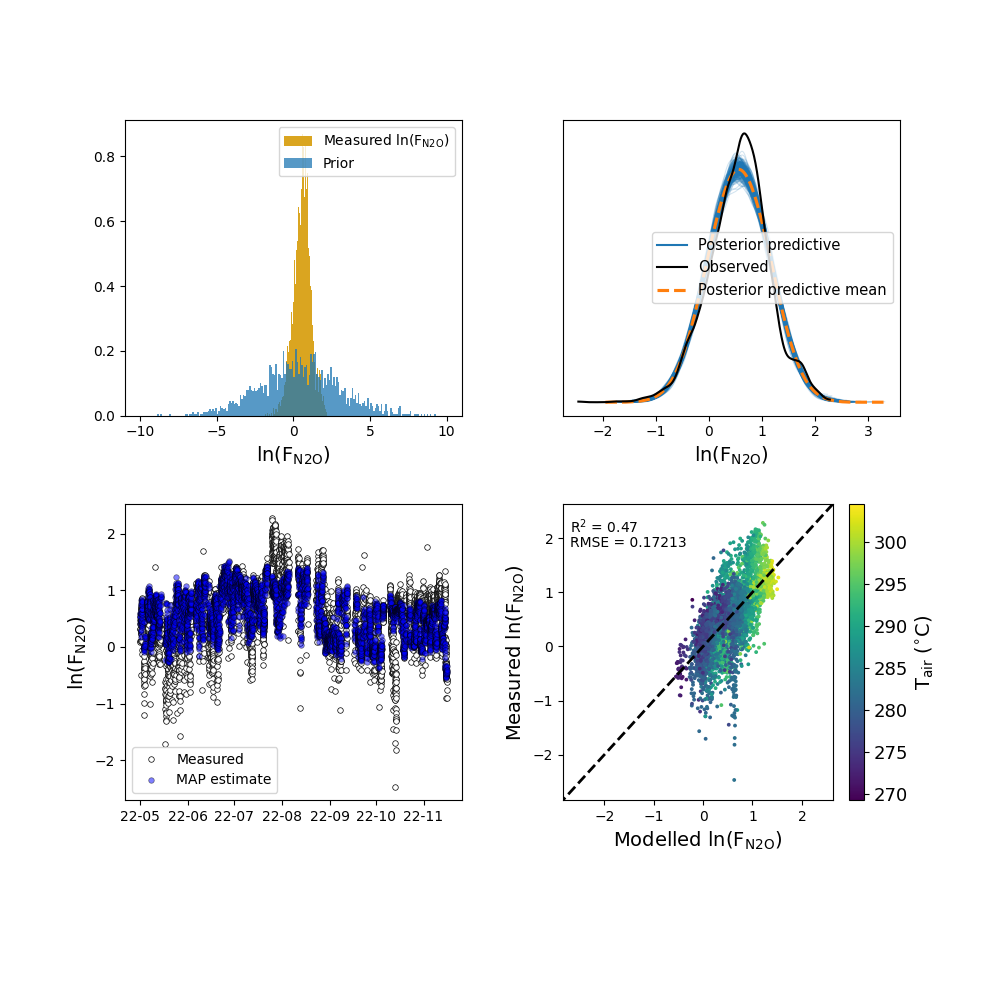

In [32]:
model = full_model_eq(full_n2o_st6['T_air'].eval(), st_6_n2o.values, map_estimate_st6, np.arange(data_n2o.shape[0]))
obs = data_n2o.loc[:, 'F_N2O_ln']

prior = idata_full_n2o_st6['prior']
data_inds = np.random.choice(st_5_n2o.shape[0], size=2000)
pp = {k:np.squeeze(v.to_numpy()) for k,v in prior.items()}
prior_values = full_model_eq(full_n2o_st6['T_air'].eval(), st_6_n2o.values, pp, data_inds)

posterior = full_n2o_st6_res

xlabel = 'ln(F$_{\mathrm{N2O}}$)'
ylabel = 'ln(F$_{\mathrm{N2O}}$)'

color_var = data_n2o.T_air_K.values
cb_label = 'T$_{\mathrm{air}}$ (K)'

visualize_fit(model, obs, prior_values, posterior, xlabel, ylabel, color_var=color_var, cb_label=cb_label, axs=None)

In [33]:
fname = 'models/full_model_n2o_st6_no_ST_T_mutable.pkl'
dict_to_save = {'model': full_n2o_st6,
                'idata': idata_full_n2o_st6,
                'model_res': full_n2o_st6_res,
                'map': map_estimate_st6,
                'data': data_n2o
                }

with open(fname, 'wb') as buff:
    cloudpickle.dump(dict_to_save, buff)

### 9 Surface types

In [34]:
full_n2o_st9, idata_full_n2o_st9 = full_model(T=data_n2o.T_air.values, X=st_9_n2o, y = data_n2o.F_N2O_ln.values)

Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma]


In [35]:
full_n2o_st9_res = fit_model(full_n2o_st9)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, gamma_mu, gamma, sigma]
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 1134 seconds.


In [36]:
with full_n2o_st9:
        map_estimate_st9, optresult = pm.find_MAP(method="L-BFGS-B", return_raw=True
    )

In [37]:
with full_n2o_st9:
    pm.sample_posterior_predictive(full_n2o_st9_res, extend_inferencedata=True)

Sampling: [obs]


/Users/opa/Ranskalankorpi_CC_EC/.venv/lib/python3.11/site-packages/xarray/core/utils.py:494: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  warnings.warn(


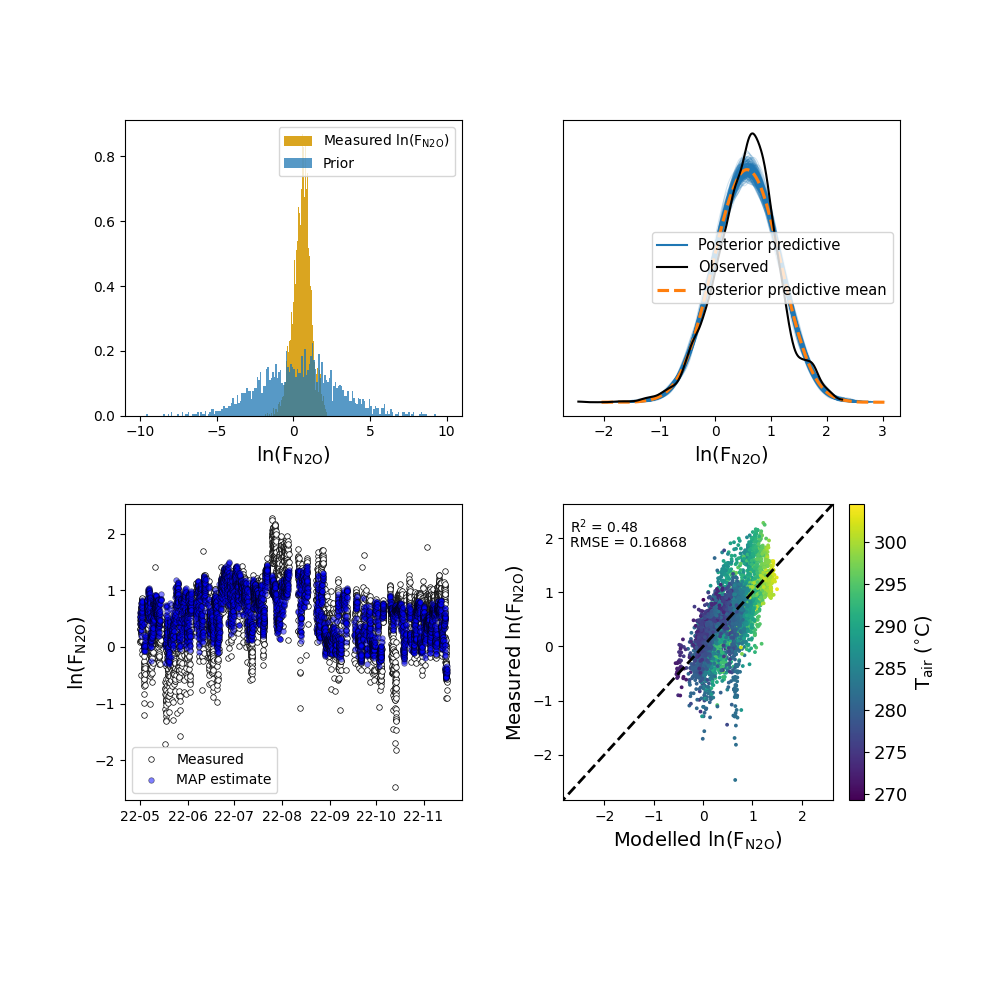

In [38]:
model = full_model_eq(full_n2o_st9['T_air'].eval(), st_9_n2o.values, map_estimate_st9, np.arange(data_n2o.shape[0]))
obs = data_n2o.loc[:, 'F_N2O_ln']

prior = idata_full_n2o_st9['prior']
data_inds = np.random.choice(st_9_n2o.shape[0], size=2000)
pp = {k:np.squeeze(v.to_numpy()) for k,v in prior.items()}
prior_values = full_model_eq(full_n2o_st9['T_air'].eval(), st_9_n2o.values, pp, data_inds)

posterior = full_n2o_st9_res

xlabel = 'ln(F$_{\mathrm{N2O}}$)'
ylabel = 'ln(F$_{\mathrm{N2O}}$)'

color_var = data_n2o.T_air_K.values
cb_label = 'T$_{\mathrm{air}}$ (K)'

visualize_fit(model, obs, prior_values, posterior, xlabel, ylabel, color_var=color_var, cb_label=cb_label, axs=None)

In [39]:
fname = 'models/full_model_n2o_st9_no_ST_T_mutable.pkl'
dict_to_save = {'model': full_n2o_st9,
                'idata': idata_full_n2o_st9,
                'model_res': full_n2o_st9_res,
                'map': map_estimate_st9,
                'data': data_n2o
                }

with open(fname, 'wb') as buff:
    cloudpickle.dump(dict_to_save, buff)

# CH<sub>4</sub> models

## CH<sub>4</sub> full model

### 3 surface types

In [41]:
full_ch4_st3, idata_full_ch4_st3 = full_model(T=data_ch4.T_air.values, X=st_3_ch4, y = data_ch4.F_CH4_ln.values)

Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma]


In [42]:
full_ch4_st3_res = fit_model(full_ch4_st3)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, gamma_mu, gamma, sigma]
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 529 seconds.


In [43]:
with full_ch4_st3:
        map_estimate_st3, optresult = pm.find_MAP(method="L-BFGS-B", return_raw=True
    )

In [44]:
with full_ch4_st3:
    pm.sample_posterior_predictive(full_ch4_st3_res, extend_inferencedata=True)

Sampling: [obs]


/Users/opa/Ranskalankorpi_CC_EC/.venv/lib/python3.11/site-packages/xarray/core/utils.py:494: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  warnings.warn(


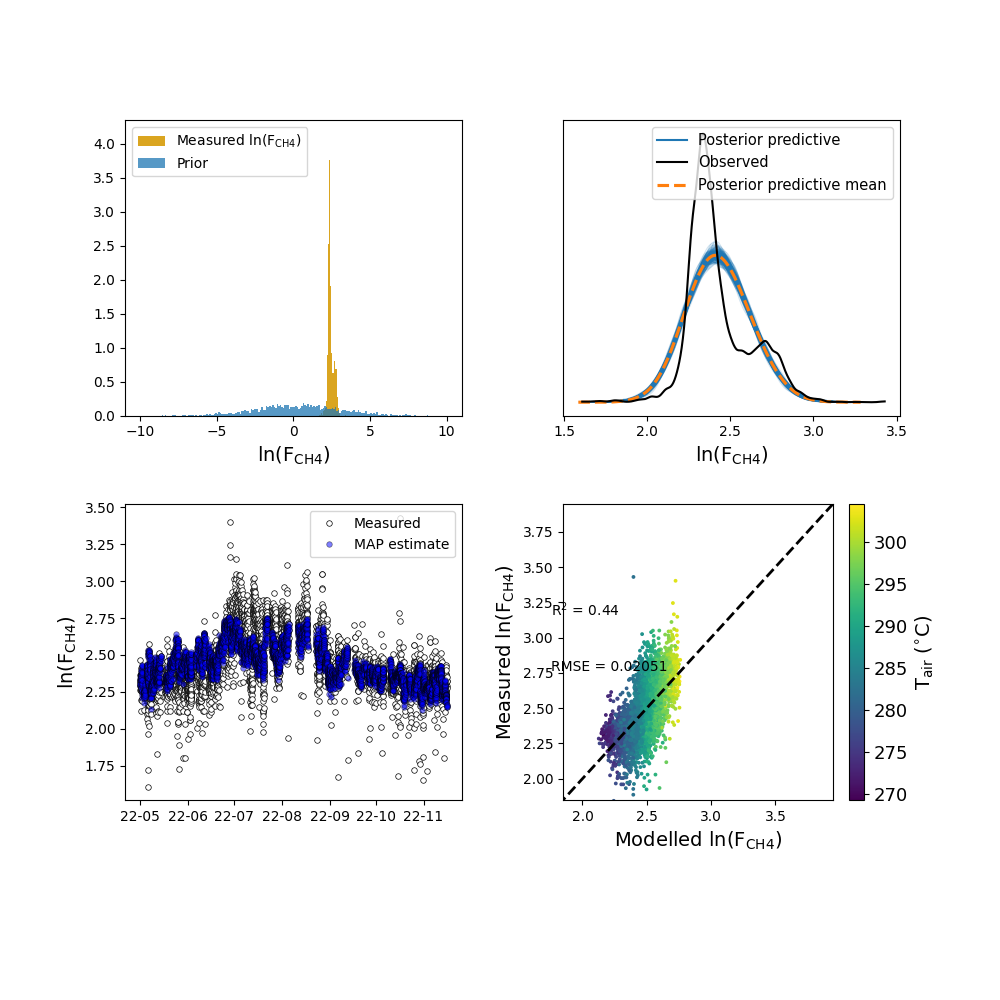

In [45]:
model = full_model_eq(full_ch4_st3['T_air'].eval(), st_3_ch4.values, map_estimate_st3, np.arange(data_ch4.shape[0]))
obs = data_ch4.loc[:, 'F_CH4_ln']

prior = idata_full_ch4_st3['prior']
data_inds = np.random.choice(st_3_ch4.shape[0], size=2000)
pp = {k:np.squeeze(v.to_numpy()) for k,v in prior.items()}
prior_values = full_model_eq(full_ch4_st3['T_air'].eval(), st_3_ch4.values, pp, data_inds)

posterior = full_ch4_st3_res

xlabel = 'ln(F$_{\mathrm{CH4}}$)'
ylabel = 'ln(F$_{\mathrm{CH4}}$)'

color_var = data_ch4.T_air_K.values
cb_label = 'T$_{\mathrm{air}}$ (K)'

visualize_fit(model, obs, prior_values, posterior, xlabel, ylabel, color_var=color_var, cb_label=cb_label, axs=None)

In [46]:
fname = 'models/full_model_ch4_st3_no_ST_T_mutable.pkl'
dict_to_save = {'model': full_ch4_st3,
                'idata': idata_full_ch4_st3,
                'model_res': full_ch4_st3_res,
                'map': map_estimate_st3,
                'data': data_ch4
                }

with open(fname, 'wb') as buff:
    cloudpickle.dump(dict_to_save, buff)

### 4 surface types

In [47]:
full_ch4_st4, idata_full_ch4_st4 = full_model(T=data_ch4.T_air.values, X=st_4_ch4, y = data_ch4.F_CH4_ln.values)

Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma]


In [48]:
full_ch4_st4_res = fit_model(full_ch4_st4)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, gamma_mu, gamma, sigma]
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 1131 seconds.


In [49]:
with full_ch4_st4:
        map_estimate_st4, optresult = pm.find_MAP(method="L-BFGS-B", return_raw=True
    )

In [50]:
with full_ch4_st4:
    pm.sample_posterior_predictive(full_ch4_st4_res, extend_inferencedata=True)

Sampling: [obs]


/Users/opa/Ranskalankorpi_CC_EC/.venv/lib/python3.11/site-packages/xarray/core/utils.py:494: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  warnings.warn(


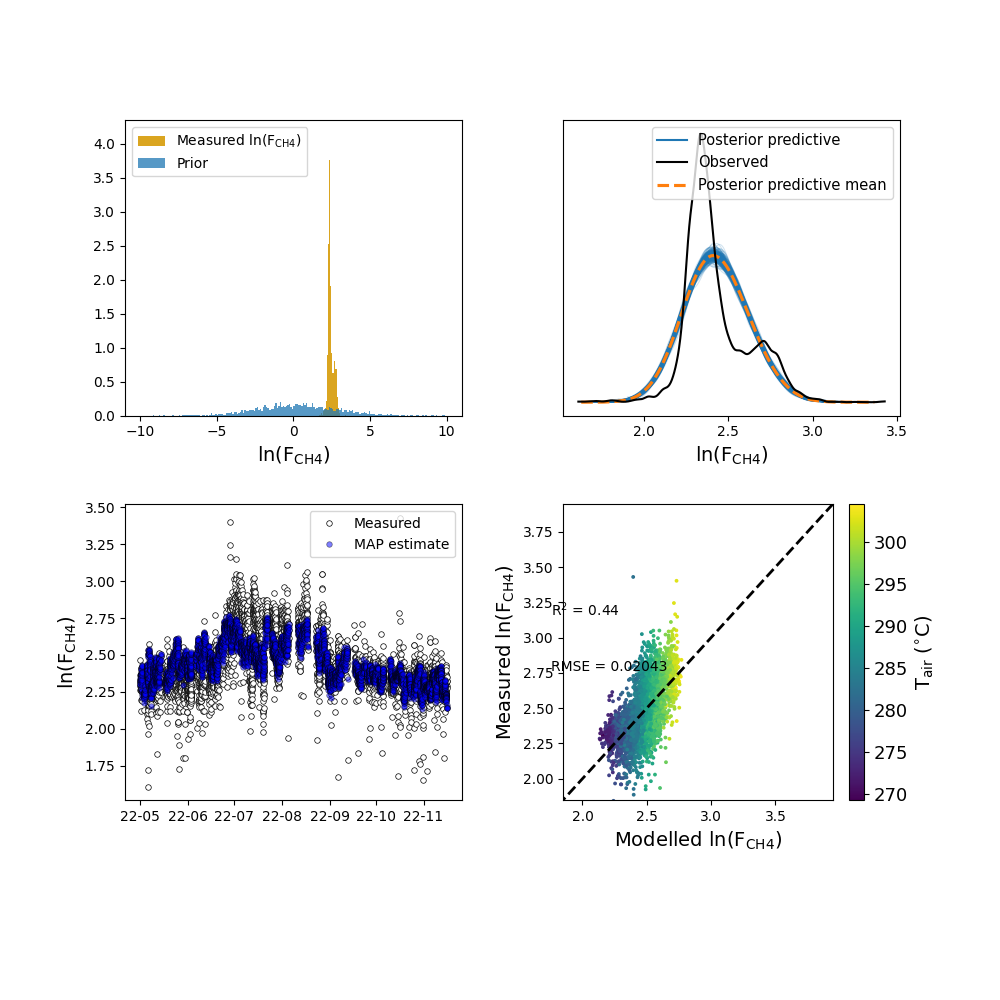

In [51]:
model = full_model_eq(full_ch4_st4['T_air'].eval(), st_4_ch4.values, map_estimate_st4, np.arange(data_ch4.shape[0]))
obs = data_ch4.loc[:, 'F_CH4_ln']

prior = idata_full_ch4_st4['prior']
data_inds = np.random.choice(st_3_ch4.shape[0], size=2000)
pp = {k:np.squeeze(v.to_numpy()) for k,v in prior.items()}
prior_values = full_model_eq(full_ch4_st4['T_air'].eval(), st_4_ch4.values, pp, data_inds)

posterior = full_ch4_st4_res

xlabel = 'ln(F$_{\mathrm{CH4}}$)'
ylabel = 'ln(F$_{\mathrm{CH4}}$)'

color_var = data_ch4.T_air_K.values
cb_label = 'T$_{\mathrm{air}}$ (K)'

visualize_fit(model, obs, prior_values, posterior, xlabel, ylabel, color_var=color_var, cb_label=cb_label, axs=None)

In [52]:
fname = 'models/full_model_ch4_st4_no_ST_T_mutable.pkl'
dict_to_save = {'model': full_ch4_st4,
                'idata': idata_full_ch4_st4,
                'model_res': full_ch4_st4_res,
                'map': map_estimate_st4,
                'data': data_ch4
                }

with open(fname, 'wb') as buff:
    cloudpickle.dump(dict_to_save, buff)

### 5 surface types

In [53]:
full_ch4_st5, idata_full_ch4_st5 = full_model(T=data_ch4.T_air.values, X=st_5_ch4, y = data_ch4.F_CH4_ln.values)

Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma]


In [54]:
full_ch4_st5_res = fit_model(full_ch4_st5)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, gamma_mu, gamma, sigma]
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 2761 seconds.


In [55]:
with full_ch4_st5:
        map_estimate_st5, optresult = pm.find_MAP(method="L-BFGS-B", return_raw=True
    )

In [56]:
with full_ch4_st5:
    pm.sample_posterior_predictive(full_ch4_st5_res, extend_inferencedata=True)

Sampling: [obs]


/Users/opa/Ranskalankorpi_CC_EC/.venv/lib/python3.11/site-packages/xarray/core/utils.py:494: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  warnings.warn(


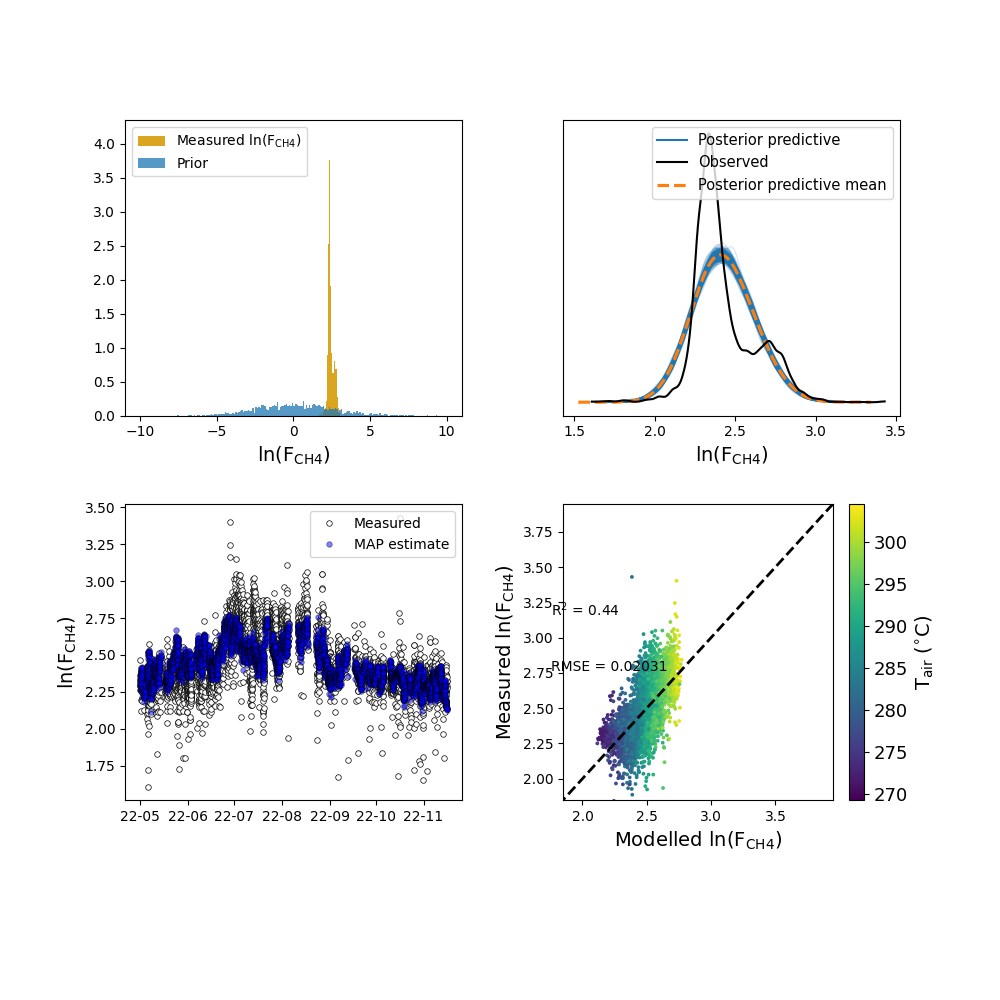

In [57]:
model = full_model_eq(full_ch4_st5['T_air'].eval(), st_5_ch4.values, map_estimate_st5, np.arange(data_ch4.shape[0]))
obs = data_ch4.loc[:, 'F_CH4_ln']

prior = idata_full_ch4_st5['prior']
data_inds = np.random.choice(st_5_ch4.shape[0], size=2000)
pp = {k:np.squeeze(v.to_numpy()) for k,v in prior.items()}
prior_values = full_model_eq(full_ch4_st5['T_air'].eval(), st_5_ch4.values, pp, data_inds)

posterior = full_ch4_st5_res

xlabel = 'ln(F$_{\mathrm{CH4}}$)'
ylabel = 'ln(F$_{\mathrm{CH4}}$)'

color_var = data_ch4.T_air_K.values
cb_label = 'T$_{\mathrm{air}}$ (K)'

visualize_fit(model, obs, prior_values, posterior, xlabel, ylabel, color_var=color_var, cb_label=cb_label, axs=None)

In [58]:
fname = 'models/full_model_ch4_st5_no_ST_T_mutable.pkl'
dict_to_save = {'model': full_ch4_st5,
                'idata': idata_full_ch4_st5,
                'model_res': full_ch4_st5_res,
                'map': map_estimate_st5,
                'data': data_ch4
                }

with open(fname, 'wb') as buff:
    cloudpickle.dump(dict_to_save, buff)

### 6 surface types

In [59]:
full_ch4_st6, idata_full_ch4_st6 = full_model(T=data_ch4.T_air.values, X=st_6_ch4, y = data_ch4.F_CH4_ln.values)

Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma]


In [60]:
full_ch4_st6_res = fit_model(full_ch4_st6)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, gamma_mu, gamma, sigma]
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 5316 seconds.


In [61]:
with full_ch4_st6:
        map_estimate_st6, optresult = pm.find_MAP(method="L-BFGS-B", return_raw=True
    )

In [62]:
with full_ch4_st6:
    pm.sample_posterior_predictive(full_ch4_st6_res, extend_inferencedata=True)

Sampling: [obs]


/Users/opa/Ranskalankorpi_CC_EC/.venv/lib/python3.11/site-packages/xarray/core/utils.py:494: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  warnings.warn(


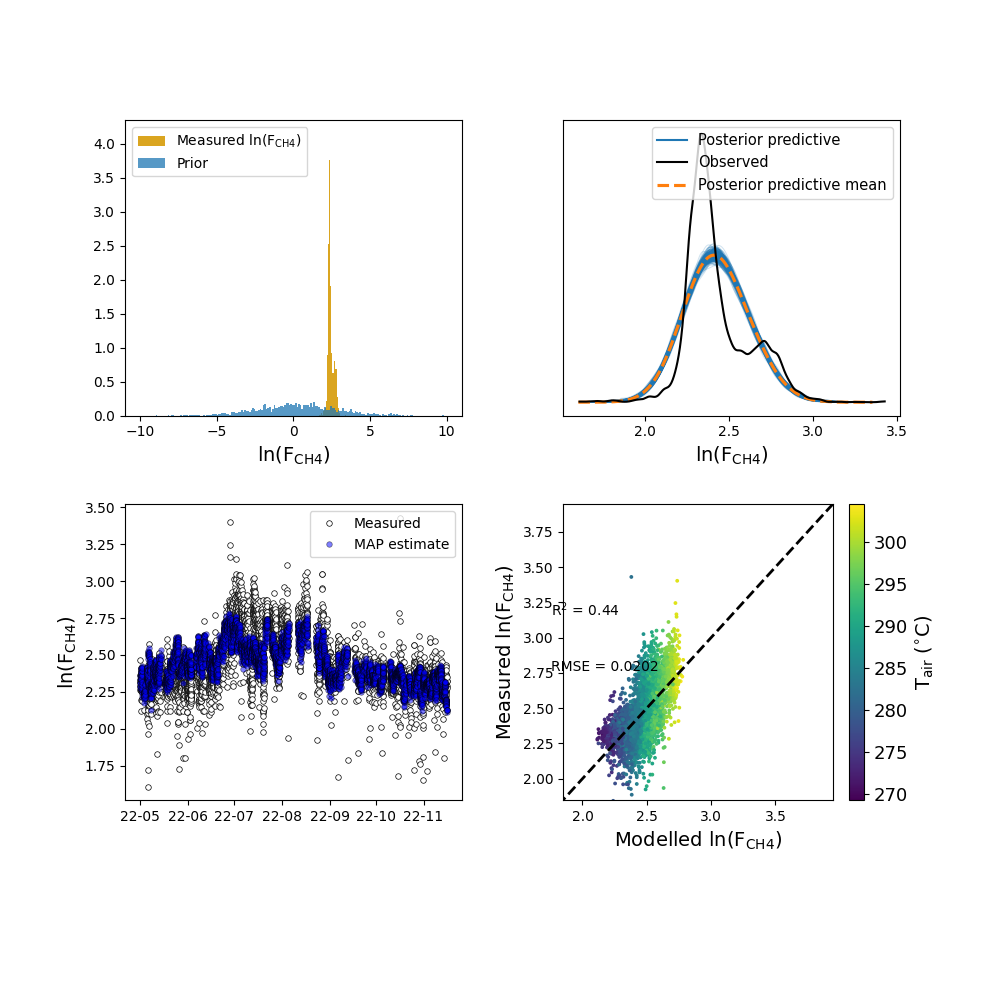

In [63]:
model = full_model_eq(full_ch4_st6['T_air'].eval(), st_6_ch4.values, map_estimate_st6, np.arange(data_ch4.shape[0]))
obs = data_ch4.loc[:, 'F_CH4_ln']

prior = idata_full_ch4_st6['prior']
data_inds = np.random.choice(st_3_ch4.shape[0], size=2000)
pp = {k:np.squeeze(v.to_numpy()) for k,v in prior.items()}
prior_values = full_model_eq(full_ch4_st6['T_air'].eval(), st_6_ch4.values, pp, data_inds)

posterior = full_ch4_st6_res

xlabel = 'ln(F$_{\mathrm{CH4}}$)'
ylabel = 'ln(F$_{\mathrm{CH4}}$)'

color_var = data_ch4.T_air_K.values
cb_label = 'T$_{\mathrm{air}}$ (K)'

visualize_fit(model, obs, prior_values, posterior, xlabel, ylabel, color_var=color_var, cb_label=cb_label, axs=None)

In [64]:
fname = 'models/full_model_ch4_st6_no_ST_T_mutable.pkl'
dict_to_save = {'model': full_ch4_st6,
                'idata': idata_full_ch4_st6,
                'model_res': full_ch4_st6_res,
                'map': map_estimate_st6,
                'data': data_ch4
                }

with open(fname, 'wb') as buff:
    cloudpickle.dump(dict_to_save, buff)

### 9 Surface types

In [65]:
full_ch4_st9, idata_full_ch4_st9 = full_model(T=data_ch4.T_air.values, X=st_9_ch4, y = data_ch4.F_CH4_ln.values)

Sampling: [alpha, beta, gamma, gamma_mu, obs, sigma]


In [66]:
full_ch4_st9_res = fit_model(full_ch4_st9)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, gamma_mu, gamma, sigma]
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 5739 seconds.


In [67]:
with full_ch4_st9:
        map_estimate_st9, optresult = pm.find_MAP(method="L-BFGS-B", return_raw=True
    )

In [68]:
with full_ch4_st9:
    pm.sample_posterior_predictive(full_ch4_st9_res, extend_inferencedata=True)

Sampling: [obs]


/Users/opa/Ranskalankorpi_CC_EC/.venv/lib/python3.11/site-packages/xarray/core/utils.py:494: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  warnings.warn(


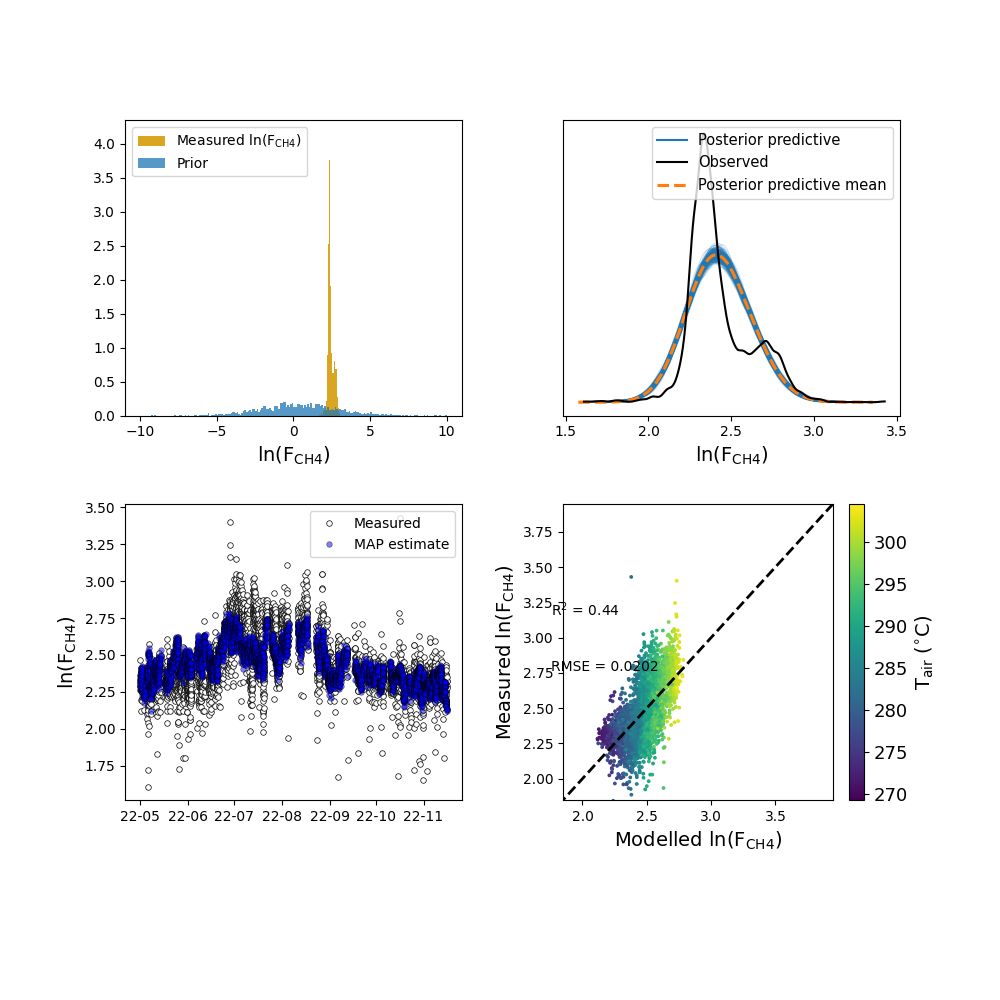

In [69]:
model = full_model_eq(full_ch4_st9['T_air'].eval(), st_9_ch4.values, map_estimate_st9, np.arange(data_ch4.shape[0]))
obs = data_ch4.loc[:, 'F_CH4_ln']

prior = idata_full_ch4_st9['prior']
data_inds = np.random.choice(st_9_ch4.shape[0], size=2000)
pp = {k:np.squeeze(v.to_numpy()) for k,v in prior.items()}
prior_values = full_model_eq(full_ch4_st9['T_air'].eval(), st_9_ch4.values, pp, data_inds)

posterior = full_ch4_st9_res

xlabel = 'ln(F$_{\mathrm{CH4}}$)'
ylabel = 'ln(F$_{\mathrm{CH4}}$)'

color_var = data_ch4.T_air_K.values
cb_label = 'T$_{\mathrm{air}}$ (K)'

visualize_fit(model, obs, prior_values, posterior, xlabel, ylabel, color_var=color_var, cb_label=cb_label, axs=None)

In [70]:
fname = 'models/full_model_ch4_st9_no_ST_T_mutable.pkl'
dict_to_save = {'model': full_ch4_st9,
                'idata': idata_full_ch4_st9,
                'model_res': full_ch4_st9_res,
                'map': map_estimate_st9,
                'data': data_ch4
                }

with open(fname, 'wb') as buff:
    cloudpickle.dump(dict_to_save, buff)